# 🎗️ 02 · De la mamografía a la detección

**Taller guiado · 20–30 minutos**

Vamos a recorrer **tres casos reales de CBIS-DDSM**. En cada caso verás primero la mamografía completa, luego sus datos básicos y por último la máscara de referencia. Ejecuta las celdas en orden y lee la explicación que sigue a cada imagen. En cada imagen podrás elegir una zona con dos controles, ver tu punto azul y después revelar la referencia. No hay preguntas ni coordenadas que escribir.

**Dos ideas para tener presentes:** la zona roja es una anotación del conjunto de datos, **no una predicción de IA**; y el resultado de patología registrado no se deduce solo por mirar la máscara. Este material es didáctico, no sirve para interpretar estudios clínicos.


## Preparación

En este proyecto, los tres pares de DICOM están en `data/taller/dicom/`. En Google Colab, la siguiente celda te pedirá subir `taller_colab.zip` si todavía no lo hiciste en esta sesión.


In [11]:
from pathlib import Path
from functools import lru_cache
import io
import json
import subprocess
import sys
import zipfile

import matplotlib.pyplot as plt
import numpy as np

try:
    import pydicom
except ImportError:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "pydicom>=3,<4", "-q"
    ])
    import pydicom

# En Colab y Jupyter usamos controles visuales. Si no están disponibles,
# se puede indicar el punto como porcentaje de la imagen.
try:
    import ipywidgets as widgets
    from IPython.display import display
except ImportError:
    widgets = None
    display = None

try:
    from google.colab import output as colab_output
    if widgets is None:
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "ipywidgets>=8,<9", "-q"
        ])
        import ipywidgets as widgets
        from IPython.display import display
    colab_output.enable_custom_widget_manager()
except ImportError:
    pass

ubicaciones = [
    Path("data/taller"),
    Path("../data/taller"),
    Path("/content/data/taller"),
]
carpeta_datos = next(
    (ruta for ruta in ubicaciones if (ruta / "casos.json").exists()),
    None,
)

if carpeta_datos is None:
    try:
        from google.colab import files
    except ImportError as error:
        raise FileNotFoundError("No encuentro la carpeta data/taller.") from error

    print("Sube el archivo taller_colab.zip")
    archivos = files.upload()
    nombre_zip = next((nombre for nombre in archivos if nombre.endswith(".zip")), None)
    if nombre_zip is None:
        raise ValueError("Se necesita taller_colab.zip para continuar.")

    with zipfile.ZipFile(io.BytesIO(archivos[nombre_zip])) as paquete:
        rutas = [Path(nombre) for nombre in paquete.namelist()]
        if any(ruta.is_absolute() or ".." in ruta.parts for ruta in rutas):
            raise ValueError("El ZIP contiene rutas no válidas.")
        paquete.extractall("/content")

    carpeta_datos = Path("/content/data/taller")

casos = json.loads((carpeta_datos / "casos.json").read_text(encoding="utf-8"))
print(f"Listo: {len(casos)} casos DICOM disponibles")


Listo: 3 casos DICOM disponibles


### Cómo se muestran los DICOM

El código siguiente lee los DICOM. Para que la mamografía se vea bien en pantalla, ajusta el contraste **solo al mostrarla**; el archivo guardado no cambia. La máscara se lee por separado. Después podrás usar las tres funciones `mostrar_imagen`, `mostrar_datos` y `mostrar_mascara` sin tocar su código.


In [12]:
@lru_cache(maxsize=3)
def leer_imagen(ruta):
    """Prepara los píxeles de un DICOM para mostrarlos en grises."""
    dicom = pydicom.dcmread(carpeta_datos / ruta)
    pixeles = dicom.pixel_array.astype(np.float32)
    valores_visibles = pixeles[pixeles > 0]

    if valores_visibles.size == 0:
        raise ValueError(f"La imagen no tiene píxeles visibles: {ruta}")

    oscuro, claro = np.percentile(valores_visibles, [0.5, 99.7])
    if claro <= oscuro:
        raise ValueError(f"No se pudo ajustar el contraste: {ruta}")

    escala = np.clip((pixeles - oscuro) / (claro - oscuro), 0, 1)
    if dicom.PhotometricInterpretation == "MONOCHROME1":
        escala = 1 - escala

    return (escala * 255).astype(np.uint8)


@lru_cache(maxsize=3)
def leer_mascara(ruta):
    """Lee los píxeles marcados en la máscara DICOM de referencia."""
    dicom = pydicom.dcmread(carpeta_datos / ruta)
    return dicom.pixel_array > 0


def mostrar_imagen(numero):
    caso = casos[numero - 1]
    imagen = leer_imagen(caso["imagen"])

    figura, eje = plt.subplots(figsize=(6, 9))
    eje.imshow(imagen, cmap="gray", vmin=0, vmax=255)
    eje.set_title(f"Caso {numero} · mamografía completa")
    eje.axis("off")
    plt.show()


def mostrar_datos(numero):
    caso = casos[numero - 1]
    lado = {"LEFT": "izquierda", "RIGHT": "derecha"}[caso["lado"]]
    tipo = {"mass": "masa", "calcification": "calcificaciones"}[caso["tipo"]]
    dicom = pydicom.dcmread(carpeta_datos / caso["imagen"], stop_before_pixels=True)

    print(f"Mama: {lado} · vista: {caso['vista']} · hallazgo anotado: {tipo}")
    print(f"DICOM: {dicom.Rows} × {dicom.Columns} píxeles · {dicom.BitsStored} bits")


controles = {}


def marcar(numero):
    """Muestra dos controles para elegir un lugar en la imagen."""
    if widgets is None:
        controles[numero] = (50, 50)
        print("Controles visuales no disponibles en este entorno.")
        print(f"Puedes cambiar el punto con: controles[{numero}] = (horizontal, vertical)")
        print("Usa números de 0 a 100. El valor inicial es (50, 50).")
        return

    horizontal = widgets.IntSlider(
        value=50, min=0, max=100, step=1,
        description="Izq. → der.", continuous_update=False,
    )
    vertical = widgets.IntSlider(
        value=50, min=0, max=100, step=1,
        description="Arriba → abajo", continuous_update=False,
    )
    controles[numero] = (horizontal, vertical)
    display(widgets.VBox([horizontal, vertical]))


def coordenadas_elegidas(numero, imagen):
    """Convierte los porcentajes elegidos a píxeles de la mamografía."""
    if numero not in controles:
        raise ValueError("Primero ejecuta la celda de los controles.")

    horizontal, vertical = controles[numero]
    valor_horizontal = horizontal.value if widgets is not None else horizontal
    valor_vertical = vertical.value if widgets is not None else vertical

    x = valor_horizontal / 100 * (imagen.shape[1] - 1)
    y = valor_vertical / 100 * (imagen.shape[0] - 1)
    return x, y


def mostrar_punto(numero):
    """Dibuja una sola vez la posición elegida; se puede repetir la celda."""
    caso = casos[numero - 1]
    imagen = leer_imagen(caso["imagen"])
    x, y = coordenadas_elegidas(numero, imagen)

    figura, eje = plt.subplots(figsize=(6, 9))
    eje.imshow(imagen, cmap="gray", vmin=0, vmax=255)
    eje.scatter(x, y, s=170, facecolors="none",
                edgecolors="#00d4ff", linewidths=2.5)
    eje.set_title(f"Caso {numero} · tu punto azul")
    eje.axis("off")
    plt.show()


def mostrar_mascara(numero):
    caso = casos[numero - 1]
    imagen = leer_imagen(caso["imagen"])
    mascara = leer_mascara(caso["mascara"])

    if imagen.shape != mascara.shape or not mascara.any():
        raise ValueError("La imagen y la máscara no coinciden.")

    capa_roja = np.zeros((*mascara.shape, 4), dtype=np.uint8)
    capa_roja[mascara] = [255, 38, 56, 128]

    x, y = coordenadas_elegidas(numero, imagen)

    figura, eje = plt.subplots(figsize=(6, 9))
    eje.imshow(imagen, cmap="gray", vmin=0, vmax=255)
    eje.imshow(capa_roja)
    eje.scatter(x, y, s=170, facecolors="none",
                edgecolors="#00d4ff", linewidths=2.5)
    eje.set_title(f"Caso {numero} · tu punto azul y la referencia roja")
    eje.axis("off")
    plt.show()

    resultado = {
        "BENIGN": "benigno",
        "BENIGN_WITHOUT_CALLBACK": "benigno",
        "MALIGNANT": "maligno",
    }.get(caso["patologia"], caso["patologia"])
    print("Resultado de patología registrado:", resultado)


## Caso 1 · Una masa

Primero observa la mamografía y sus datos básicos. Después podrás colocar tu punto azul antes de ver la referencia.


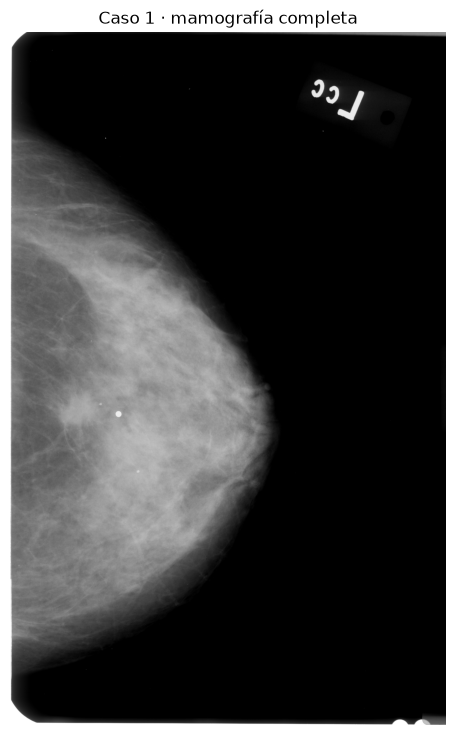

Mama: izquierda · vista: CC · hallazgo anotado: masa
DICOM: 4808 × 3024 píxeles · 16 bits


In [13]:
mostrar_imagen(1)
mostrar_datos(1)


Mueve los dos controles para elegir la zona que revisarías. **No hace falta tocar el código.** El punto se dibuja al ejecutar la celda siguiente.


In [27]:
marcar(1)


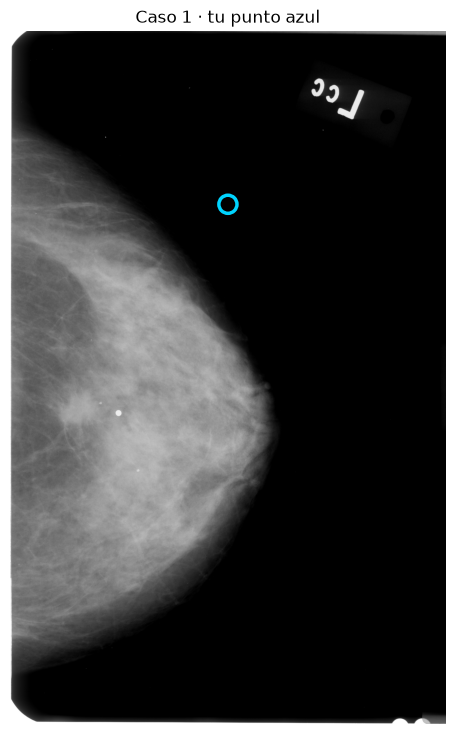

In [33]:
mostrar_punto(1)


Si quieres cambiar tu elección, mueve los controles y vuelve a ejecutar **solo** la celda del punto. Cuando estés conforme, ejecuta la siguiente para revelar la máscara.


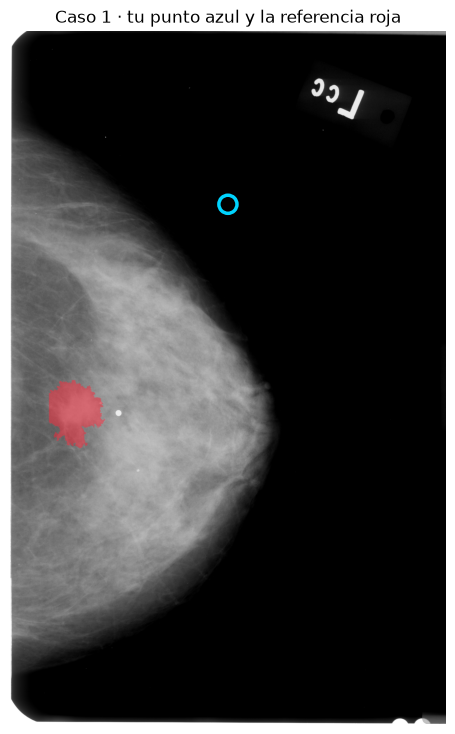

Resultado de patología registrado: maligno


In [34]:
mostrar_mascara(1)


El punto azul es tu elección; la zona roja es la anotación de referencia. El resultado de patología registrado para este caso es **maligno**. El rojo muestra la ubicación anotada, no la gravedad.


## Caso 2 · Otra masa

Repite el mismo orden: imagen y datos, controles, punto azul y máscara.


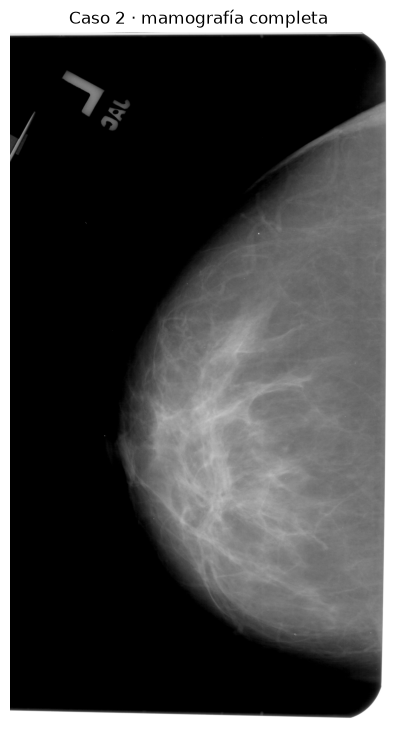

Mama: izquierda · vista: CC · hallazgo anotado: masa
DICOM: 5491 × 2986 píxeles · 16 bits


In [17]:
mostrar_imagen(2)
mostrar_datos(2)


In [18]:
marcar(2)


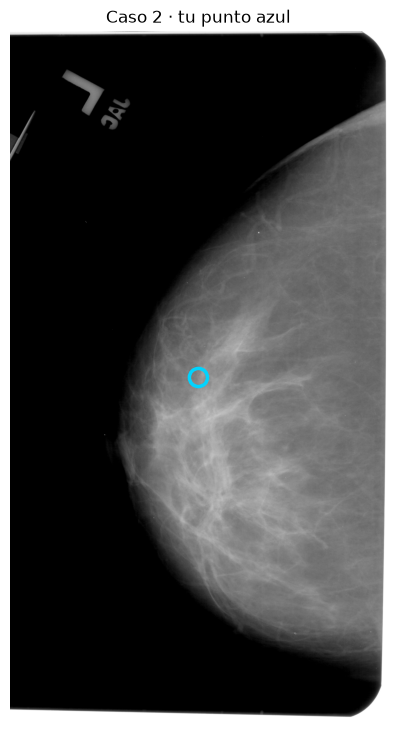

In [19]:
mostrar_punto(2)


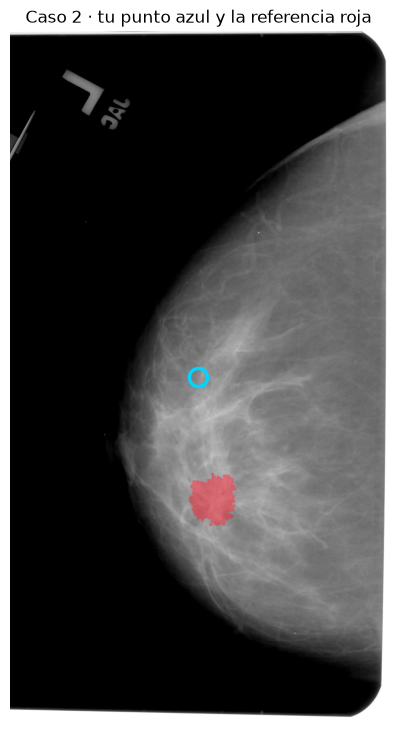

Resultado de patología registrado: benigno


In [20]:
mostrar_mascara(2)


El resultado registrado del caso 2 es **benigno**. Estos dos casos ilustran que **«masa» no significa automáticamente «cáncer»**.


## Caso 3 · Calcificaciones

Aquí el hallazgo anotado son calcificaciones. Observa la imagen, coloca tu punto y después revela la referencia.


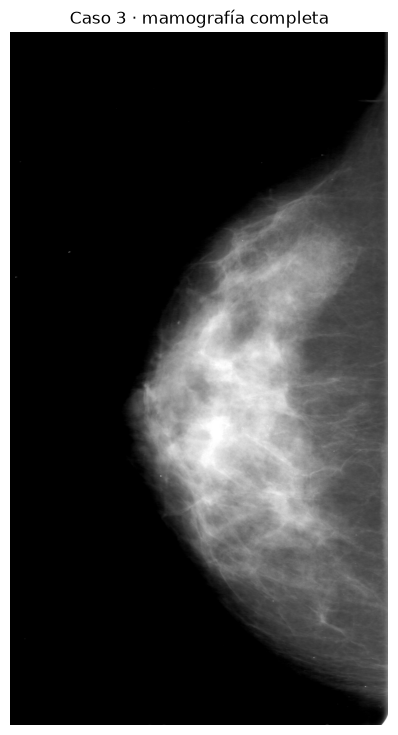

Mama: derecha · vista: CC · hallazgo anotado: calcificaciones
DICOM: 5056 × 2761 píxeles · 16 bits


In [35]:
mostrar_imagen(3)
mostrar_datos(3)


In [22]:
marcar(3)


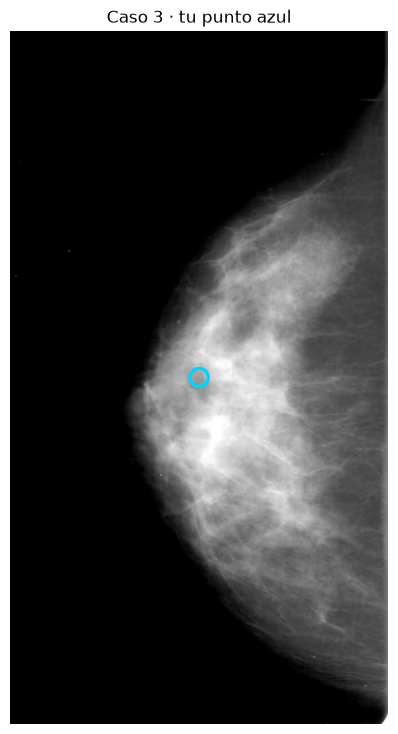

In [23]:
mostrar_punto(3)


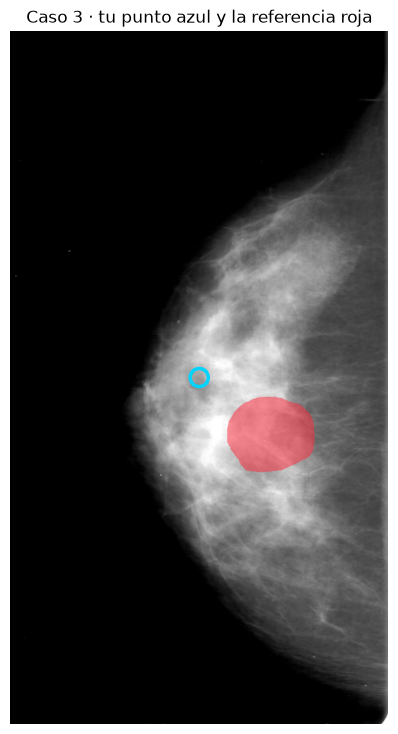

Resultado de patología registrado: maligno


In [24]:
mostrar_mascara(3)


El resultado registrado del caso 3 es **maligno**. Ver puntos claros en una mamografía no basta por sí solo para llegar a ese resultado.

## Para cerrar

Has visto cada mamografía, elegido una región y comparado tu punto con su máscara de referencia. Los archivos son copias DICOM de CBIS-DDSM; la carpeta de origen no se modifica. Este cuaderno **no entrena ni evalúa una IA**.

**Fuente:** [CBIS-DDSM, The Cancer Imaging Archive](https://www.cancerimagingarchive.net/collection/cbis-ddsm/) (CC BY 3.0). El contraste se ajusta solo para mostrar las imágenes en pantalla. Material didáctico, no apto para interpretación clínica.
